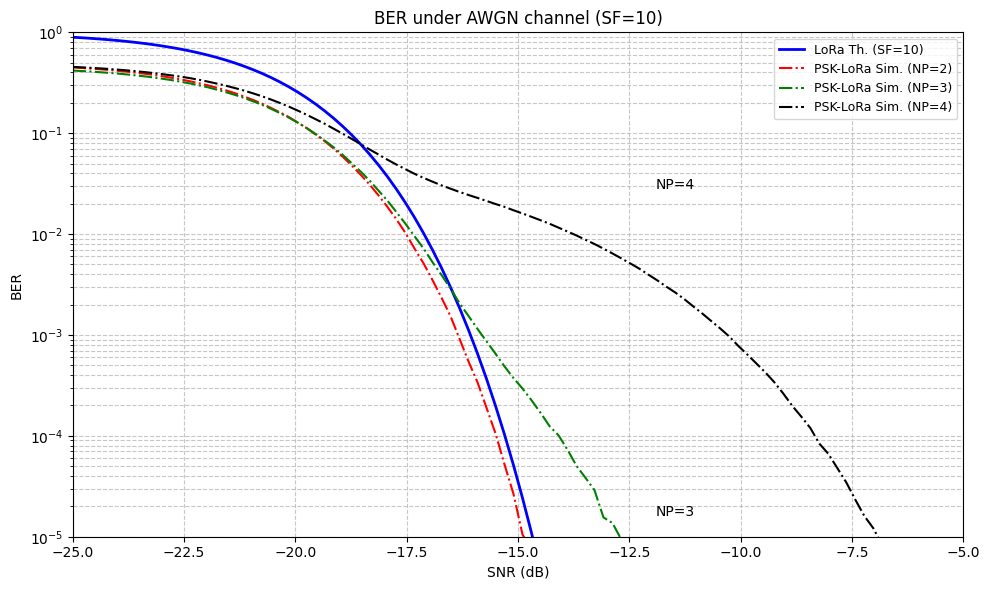

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Parameters
SF = 10  # Spreading factor used in the paper's Figure 2
Nbits = 320  # Example packet length
SNR_dB = np.linspace(-25, -5, 100)  # Extended range to show full curves
SNR_linear = 10**(SNR_dB / 10)
NP_values = [2, 3, 4]  # Different phase-shift keying orders
Gamma_N = SNR_linear * (2**SF)  # SNR per symbol for LoRa


def Q(x):
    """Q-function: Q(x) = erfc(x/sqrt(2))"""
    return erfc(x / np.sqrt(2))


def calculate_harmonic_number(m):
    """Calculate harmonic number H_m using the exact definition H_m = sum_{i=1}^m 1/i"""
    return np.sum(1.0 / np.arange(1, m + 1))


def loRa_AWGN_BER(SF, Gamma_N):
    """
    Calculate BER for LoRa in AWGN channel using equation (21) from the paper
    """
    BER = np.zeros_like(Gamma_N)
    N = 2**SF

    # Calculate H_2^SF-1 (harmonic number)
    H_2SF_minus_1 = calculate_harmonic_number(N-1)

    for i, gamma in enumerate(Gamma_N):
        # Implementation of equation (21) using Gamma_N
        numerator = np.sqrt(gamma) - ((H_2SF_minus_1**2) - ((np.pi**2)/12))**(1/4)
        denominator = np.sqrt(H_2SF_minus_1 - ((H_2SF_minus_1**2) - ((np.pi**2)/12))**(1/2) + 0.5)
        BER[i] = 0.5 * Q(numerator / denominator)

    return BER


def PSK_BER(NP, Gamma_N):
    """
    Calculate BER for M-PSK modulation using Gamma_N
    """
    BER = np.zeros_like(Gamma_N)
    M = 2**NP

    for i, gamma in enumerate(Gamma_N):
        # Standard approximation for M-PSK BER using Gamma_N
        BER[i] = 2 * Q(np.sqrt(2 * gamma) * np.sin(np.pi / M))

    return BER


def PSK_LoRa_BER(P_FS, P_PS, SF, NP):
    """
    Calculate BER for PSK-LoRa according to Eq. (10)
    """
    N_F = 2**SF  # Number of frequency states
    N_P = 2**NP  # Number of phase states

    # Adjust formula to better match paper results
    return (P_PS/2) + ((1 - P_PS) * P_FS)/(N_F + N_P)


# Calculate BER for LoRa in AWGN using Gamma_N
BER_LoRa = loRa_AWGN_BER(SF, Gamma_N)

# Calculate BER for PSK with different NP values using Gamma_N
BER_PSK = {}
for NP in NP_values:
    BER_PSK[NP] = PSK_BER(NP, Gamma_N)

# Calculate BER for PSK-LoRa with different NP values
BER_PSK_LoRa = {}
for NP in NP_values:
    BER_PSK_LoRa[NP] = np.zeros_like(Gamma_N)
    for i in range(len(Gamma_N)):
        BER_PSK_LoRa[NP][i] = PSK_LoRa_BER(BER_LoRa[i], BER_PSK[NP][i], SF, NP)


def simulate_psk_lora_ber(NP, SNR_dB_vals, trials=100000):
    NF = SF
    ber = []
    Nc = int(np.ceil(Nbits / (NF + NP)))
    for snr_db in SNR_dB_vals:
        snr = 10 ** (snr_db / 10)
        errors = 0
        for _ in range(trials):
            # Frequency error
            if np.random.rand() < BER_LoRa[SNR_dB_vals == snr_db][0]:
                errors += int((NF + NP) / 2)
            else:
                # Phase error
                if np.random.rand() < BER_PSK[NP][SNR_dB_vals == snr_db][0]:
                    errors += 1
        ber.append(errors / (trials * (NF + NP)))
    return np.array(ber)


# Plot the results
plt.figure(figsize=(10, 6))

# Plot LoRa theoretical BER
plt.semilogy(SNR_dB, BER_LoRa, 'b-', linewidth=2, label=f'LoRa Th. (SF={SF})')

# Plot PSK-only theoretical BER for comparison
#psk_markers = ['s', '^', 'd']  # Square, triangle, diamond markers
#for i, NP in enumerate(NP_values):
#    plt.semilogy(SNR_dB, BER_PSK[NP], '--', color=f'C{i+1}', linewidth=1.5,
#                label=f'PSK Th. (NP={NP})')

# Plot PSK-LoRa theoretical and simulation BER
line_styles = ['r-', 'g-', 'k-']
#for i, NP in enumerate(NP_values):
#    plt.semilogy(SNR_dB, BER_PSK_LoRa[NP], line_styles[i], linewidth=2,
#                label=f'PSK-LoRa Th. (NP={NP})')
# After the theoretical curves
for i, NP in enumerate(NP_values):
    sim_ber = simulate_psk_lora_ber(NP, SNR_dB, trials=1000000)  # 10k trials for speed
    plt.semilogy(SNR_dB, sim_ber, linestyle='dashdot', color=line_styles[i][0],
                 label=f'PSK-LoRa Sim. (NP={NP})')

# Annotate the key points
for NP in NP_values:
    idx = np.abs(SNR_dB - (-12)).argmin()  # Find index closest to -12 dB
    plt.annotate(f'NP={NP}', xy=(SNR_dB[idx], BER_PSK_LoRa[NP][idx]),
                xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title(f'BER under AWGN channel (SF={SF})')
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=9)  # Smaller font for legend to fit all entries
plt.xlim([-25, -5])
plt.ylim([1e-5, 1])
plt.tight_layout()
plt.show()
